In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense,Dropout,Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
df_train=pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test=pd.read_csv('/content/sample_data/california_housing_test.csv')

In [ ]:
df_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [ ]:
X_train=df_train.drop('median_house_value',axis=1)
y_train=df_train['median_house_value']

In [ ]:
X_test=df_test.drop('median_house_value',axis=1)
y_test=df_test['median_house_value']

In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train.shape,X_test.shape

((17000, 8), (3000, 8))

In [ ]:
model=Sequential()
model.add(Dense(64,activation='relu',input_shape=(8,)))
model.add(Dropout(0.25))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.01),loss='mse',metrics=['mse'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=500, validation_split = 0.20,verbose=1)


Epoch 1/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 29365487616.0000 - mse: 29365487616.0000 - val_loss: 42403737600.0000 - val_mse: 42403737600.0000
Epoch 2/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9589743616.0000 - mse: 9589743616.0000 - val_loss: 13309470720.0000 - val_mse: 13309470720.0000
Epoch 3/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6456484352.0000 - mse: 6456484352.0000 - val_loss: 7251897344.0000 - val_mse: 7251897344.0000
Epoch 4/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5757885440.0000 - mse: 5757885440.0000 - val_loss: 6279302144.0000 - val_mse: 6279302144.0000
Epoch 5/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5639578112.0000 - mse: 5639578112.0000 - val_loss: 5924616704.0000 - val_mse: 5924616704.0000
Epoch 6/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5429279744.0000 - mse: 5429279744.0000 - val_loss: 5966755328.0000 - val_mse: 5966755328.0000
Epoch 7/500
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 539

In [ ]:
train_mse, train_mae = model.evaluate(X_train_scaled, y_train)
test_mse, test_mae = model.evaluate(X_test_scaled, y_test)

532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4065373952.0000 - mse: 4065373952.0000
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4185144576.0000 - mse: 4185144576.0000


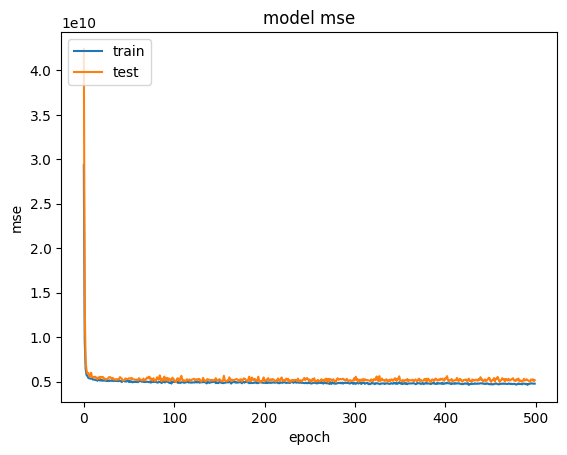

In [ ]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

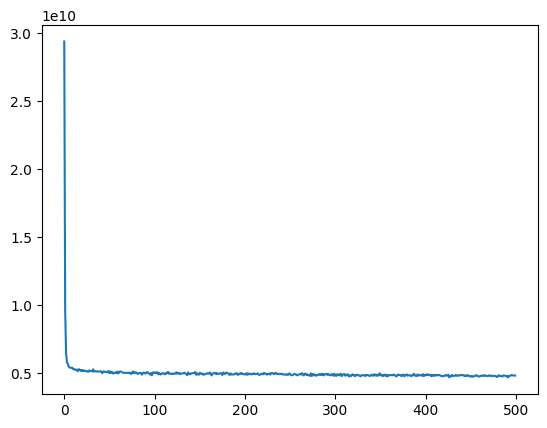

In [ ]:
plt.plot(history.history['loss'])